# ♻️ Lab 5 — Implementation of ResNet50
## Smart Waste Classification using Transfer Learning (ResNet50)

---

### 📋 Lab Overview

| Field | Details |
|---|---|
| **Lab Name** | Implementation of ResNet50 |
| **Dataset** | Synthetic Waste Classification Images (6 categories, 1800 images) |
| **Domain** | Environmental AI / Image Classification |
| **Tools Used** | TensorFlow, Keras, ResNet50, NumPy, Matplotlib, Scikit-learn |

---

### 🎯 Problem Statement

> **Can a fine-tuned ResNet50 model accurately classify waste materials into 6 recycling categories to enable automated smart waste sorting?**
>
> Improper waste segregation is one of the leading causes of recycling inefficiency globally. An automated vision-based system could identify waste type in real time on conveyor belts. We fine-tune a pre-trained ResNet50 model using transfer learning to classify waste into: Paper, Plastic, Glass, Metal, Cardboard, and Organic waste.

### 🎓 Learning Objectives
- Understand residual connections and the ResNet50 architecture
- Apply transfer learning by loading ImageNet pre-trained weights
- Implement fine-tuning — freeze base layers, train classifier head, then unfreeze top layers
- Compare baseline (feature extraction) vs fine-tuned performance
- Evaluate using accuracy, F1-score, ROC curves, and confusion matrix

---
## 📦 Section 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded!')
print(f'   TensorFlow: {tf.__version__}')

✅ Libraries loaded!
   TensorFlow: 2.19.0


---
## 🗑️ Section 2: Synthetic Waste Dataset Generation

6 waste categories with **300 images each** (1800 total), sized **96×96 RGB** with class-distinct color and texture patterns:

| Class | Color Profile | Visual Pattern |
|---|---|---|
| Paper | Off-white / beige | Uniform low-texture |
| Plastic | Bright multi-color | Glossy smooth patches |
| Glass | Blue/green tint | High transparency patterns |
| Metal | Silver/grey | Reflective grid texture |
| Cardboard | Brown/tan | Ribbed corrugated texture |
| Organic | Green/brown | Irregular organic shapes |

Generating Paper...
Generating Plastic...
Generating Glass...
Generating Metal...
Generating Cardboard...
Generating Organic...

✅ Dataset: 1800 images | Shape: (96, 96, 3) | Classes: 6


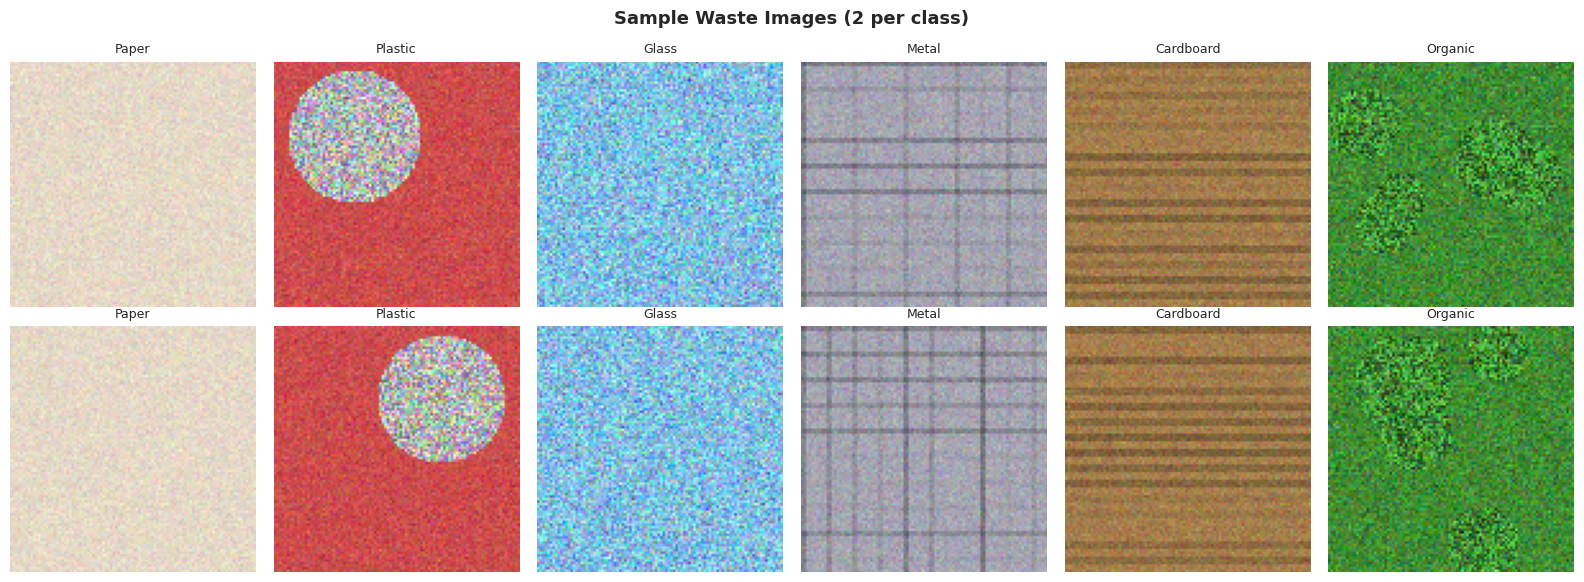

In [2]:
np.random.seed(42)
N_PER_CLASS = 300
IMG_SIZE    = 96
CLASS_NAMES = ['Paper', 'Plastic', 'Glass', 'Metal', 'Cardboard', 'Organic']
N_CLASSES   = len(CLASS_NAMES)

CLASS_PROFILES = {
    'Paper'    : {'base': [0.90, 0.85, 0.78], 'noise': 0.04, 'texture': 'uniform'},
    'Plastic'  : {'base': [0.80, 0.30, 0.30], 'noise': 0.06, 'texture': 'glossy'},
    'Glass'    : {'base': [0.50, 0.75, 0.90], 'noise': 0.08, 'texture': 'transparent'},
    'Metal'    : {'base': [0.65, 0.65, 0.70], 'noise': 0.05, 'texture': 'grid'},
    'Cardboard': {'base': [0.65, 0.50, 0.30], 'noise': 0.05, 'texture': 'ribbed'},
    'Organic'  : {'base': [0.25, 0.55, 0.20], 'noise': 0.09, 'texture': 'organic'},
}

def generate_class_images(class_name, n):
    p = CLASS_PROFILES[class_name]
    imgs = np.ones((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    base = np.array(p['base'])

    for i in range(n):
        img = np.tile(base, (IMG_SIZE, IMG_SIZE, 1)).astype(np.float32)

        if p['texture'] == 'grid':
            for x in range(0, IMG_SIZE, 10):
                img[x:x+2, :, :] *= np.random.uniform(0.7, 1.0)
                img[:, x:x+2, :] *= np.random.uniform(0.7, 1.0)
        elif p['texture'] == 'ribbed':
            for x in range(0, IMG_SIZE, 6):
                img[x:x+3, :, :] *= np.random.uniform(0.75, 1.0)
        elif p['texture'] == 'glossy':
            cx, cy = np.random.randint(20,76,2)
            r = np.random.randint(15, 30)
            for x in range(max(0,cx-r), min(IMG_SIZE,cx+r)):
                for y in range(max(0,cy-r), min(IMG_SIZE,cy+r)):
                    if (x-cx)**2 + (y-cy)**2 < r**2:
                        img[x,y] = np.random.uniform(0.4, 1.0, 3)
        elif p['texture'] == 'organic':
            for _ in range(np.random.randint(3,8)):
                cx,cy = np.random.randint(10,86,2)
                r = np.random.randint(8,20)
                for x in range(max(0,cx-r), min(IMG_SIZE,cx+r)):
                    for y in range(max(0,cy-r), min(IMG_SIZE,cy+r)):
                        if (x-cx)**2 + (y-cy)**2 < r**2:
                            img[x,y] = base * np.random.uniform(0.5, 1.5)
        elif p['texture'] == 'transparent':
            img += np.random.normal(0, 0.12, (IMG_SIZE, IMG_SIZE, 3))

        img += np.random.normal(0, p['noise'], (IMG_SIZE, IMG_SIZE, 3))
        imgs[i] = np.clip(img, 0, 1)
    return imgs

all_images = []
all_labels = []
for idx, cls in enumerate(CLASS_NAMES):
    print(f'Generating {cls}...')
    imgs = generate_class_images(cls, N_PER_CLASS)
    all_images.append(imgs)
    all_labels.extend([idx] * N_PER_CLASS)

X = np.concatenate(all_images, axis=0)
y = np.array(all_labels)

print(f'\n✅ Dataset: {X.shape[0]} images | Shape: {X.shape[1:]} | Classes: {N_CLASSES}')

# Visualize
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for cls in range(N_CLASSES):
    idx = np.where(y == cls)[0]
    axes[0, cls].imshow(X[idx[0]])
    axes[0, cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[0, cls].axis('off')
    axes[1, cls].imshow(X[idx[1]])
    axes[1, cls].set_title(CLASS_NAMES[cls], fontsize=9)
    axes[1, cls].axis('off')
plt.suptitle('Sample Waste Images (2 per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Section 3: Preprocessing for ResNet50

ResNet50 expects **224×224 images** preprocessed with `preprocess_input()` (ImageNet mean subtraction). We resize and preprocess our images accordingly.

In [3]:
RESNET_SIZE = 224

# Resize to 224x224 for ResNet50
X_resized = tf.image.resize(X, [RESNET_SIZE, RESNET_SIZE]).numpy()
X_processed = preprocess_input(X_resized * 255.0)  # preprocess_input expects 0-255

y_cat = to_categorical(y, N_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed, y_cat, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Input shape per image: {X_train.shape[1:]}')

Train: 1260 | Val: 270 | Test: 270
Input shape per image: (224, 224, 3)


---
## 🏗️ Section 4: Build ResNet50 Transfer Learning Model

### Strategy: Two-Phase Fine-Tuning

**Phase 1 — Feature Extraction:** Freeze all ResNet50 base layers. Train only the custom classifier head. This quickly adapts the head to our task.

**Phase 2 — Fine-Tuning:** Unfreeze the top 30 layers of ResNet50. Train with a very low learning rate to adapt high-level features.

In [4]:
def build_resnet_model(trainable_base=False, unfreeze_last_n=0):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(RESNET_SIZE, RESNET_SIZE, 3)
    )

    # Freeze all by default
    base_model.trainable = trainable_base

    # Optionally unfreeze last N layers
    if unfreeze_last_n > 0:
        for layer in base_model.layers[-unfreeze_last_n:]:
            layer.trainable = True

    inputs  = keras.Input(shape=(RESNET_SIZE, RESNET_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(N_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f'WasteClassifier_ResNet50')
    return model, base_model

# Phase 1: Feature Extraction
model, base_model = build_resnet_model(trainable_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params    = model.count_params()
trainable       = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable:,} (Phase 1 — head only)')
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total params     : 24,771,718
Trainable params : 1,182,982 (Phase 1 — head only)


Model: "WasteClassifier_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,718 (94.50 MB)

 Trainable params: 1,182,982 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

---
## 🏋️ Section 5: Phase 1 Training — Feature Extraction

In [5]:
callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=4, verbose=1)
]

print('=== Phase 1: Feature Extraction ===')
history_p1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks_p1,
    verbose=1
)

loss_p1, acc_p1 = model.evaluate(X_test, y_test, verbose=0)
print(f'\nPhase 1 Test Accuracy: {acc_p1*100:.2f}%')

=== Phase 1: Feature Extraction ===
Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 307s 7s/step - accuracy: 0.8948 - loss: 0.3191 - val_accuracy: 1.0000 - val_loss: 2.5187e-04 - learning_rate: 0.0010
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 288s 7s/step - accuracy: 1.0000 - loss: 2.1119e-04 - val_accuracy: 1.0000 - val_loss: 3.4741e-05 - learning_rate: 0.0010
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 247s 6s/step - accuracy: 1.0000 - loss: 7.3533e-05 - val_accuracy: 1.0000 - val_loss: 9.9109e-06 - learning_rate: 0.0010
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 259s 7s/step - accuracy: 1.0000 - loss: 5.6881e-05 - val_accuracy: 1.0000 - val_loss: 3.4301e-06 - learning_rate: 0.0010
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 260s 7s/step - accuracy: 1.0000 - loss: 2.4942e-05 - val_accuracy: 1.0000 - val_loss: 1.3736e-06 - learning_rate: 0.0010
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 4.7931e-05
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
40/40 ━━━━

---
## 🔧 Section 6: Phase 2 Training — Fine-Tuning

In [6]:
print('=== Phase 2: Fine-Tuning (unfreezing top 30 layers) ===')

# Unfreeze top 30 layers of base
for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

# Recompile with very low LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_ft = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Trainable params after unfreeze: {trainable_ft:,}')

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                   restore_best_weights=True, verbose=1),
]

history_p2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    callbacks=callbacks_p2,
    verbose=1
)

loss_p2, acc_p2 = model.evaluate(X_test, y_test, verbose=0)
print(f'\nPhase 2 Test Accuracy: {acc_p2*100:.2f}%')
print(f'Improvement from fine-tuning: +{(acc_p2 - acc_p1)*100:.2f}%')

=== Phase 2: Fine-Tuning (unfreezing top 30 layers) ===
Trainable params after unfreeze: 15,611,654
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 416s 5s/step - accuracy: 1.0000 - loss: 4.7886e-05 - val_accuracy: 1.0000 - val_loss: 1.1877e-07
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 1.0000 - loss: 2.0520e-05 - val_accuracy: 1.0000 - val_loss: 6.8435e-08
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 411s 5s/step - accuracy: 1.0000 - loss: 1.3401e-05 - val_accuracy: 1.0000 - val_loss: 4.9008e-08
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step - accuracy: 1.0000 - loss: 1.8871e-05 - val_accuracy: 1.0000 - val_loss: 5.1216e-08
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 1.0000 - loss: 9.2612e-06 - val_accuracy: 1.0000 - val_loss: 1.2804e-08
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 375s 5s/step - accuracy: 1.0000 - loss: 7.9844e-06 - val_accuracy: 1.0000 - val_loss: 2.2076e-09
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 379s 5s/step - accuracy: 1.0000 - loss: 5.1486e-06 -

---
## 📊 Section 7: Full Evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step
=== Classification Report ===
              precision    recall  f1-score   support

       Paper       1.00      1.00      1.00        40
     Plastic       1.00      1.00      1.00        46
       Glass       1.00      1.00      1.00        56
       Metal       1.00      1.00      1.00        43
   Cardboard       1.00      1.00      1.00        43
     Organic       1.00      1.00      1.00        42

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



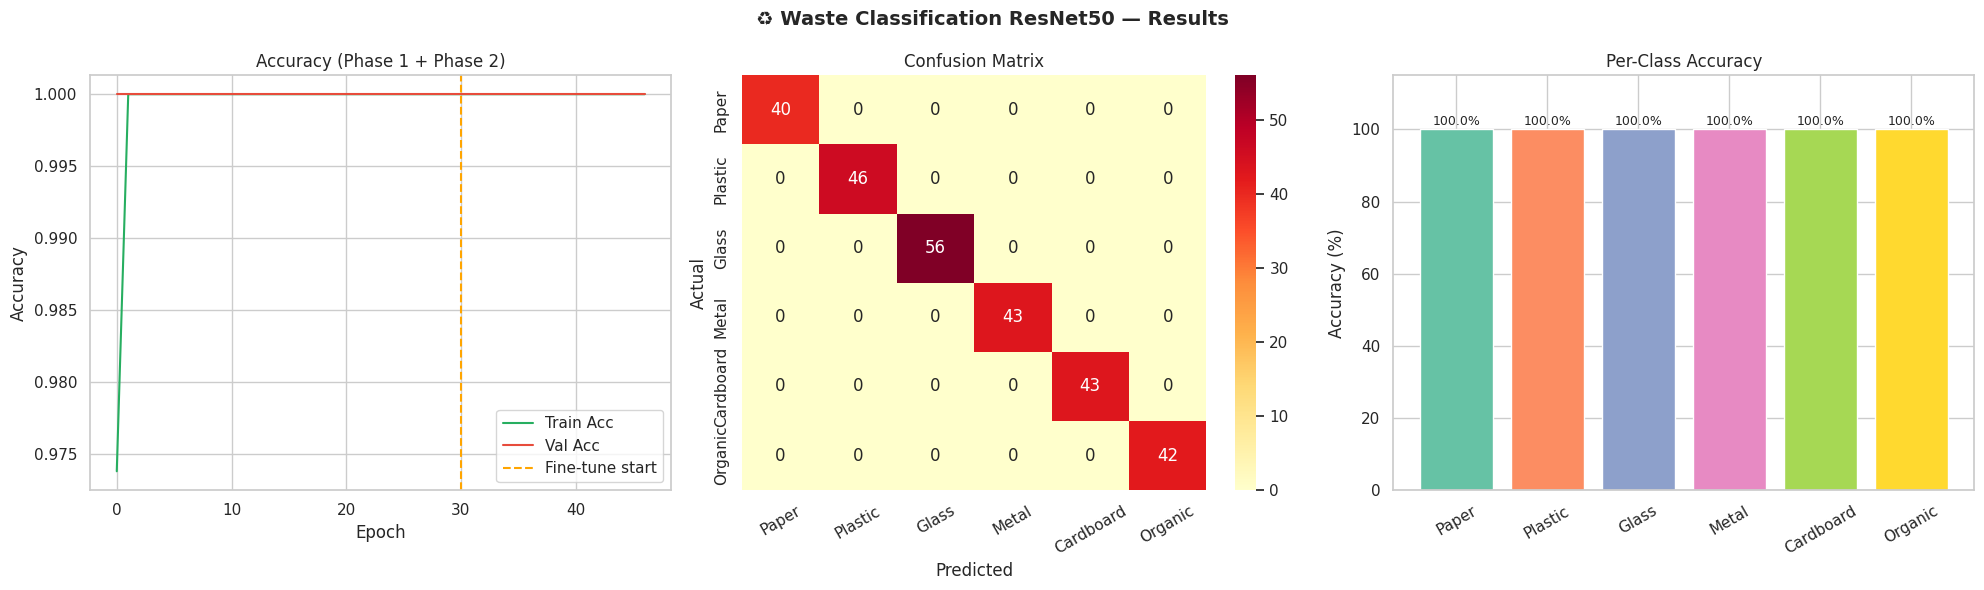

In [7]:
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Combined accuracy curves
all_train_acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
all_val_acc   = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
split_epoch   = len(history_p1.history['accuracy'])

axes[0].plot(all_train_acc, label='Train Acc', color='#27AE60')
axes[0].plot(all_val_acc,   label='Val Acc',   color='#E74C3C')
axes[0].axvline(split_epoch, color='orange', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy (Phase 1 + Phase 2)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)

# Per-class accuracy bar
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = axes[2].bar(CLASS_NAMES, per_class_acc * 100,
                   color=sns.color_palette('Set2', N_CLASSES))
for bar, acc in zip(bars, per_class_acc):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
axes[2].set_title('Per-Class Accuracy')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_ylim(0, 115)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('♻️ Waste Classification ResNet50 — Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📈 Section 8: ROC Curves (One-vs-Rest)

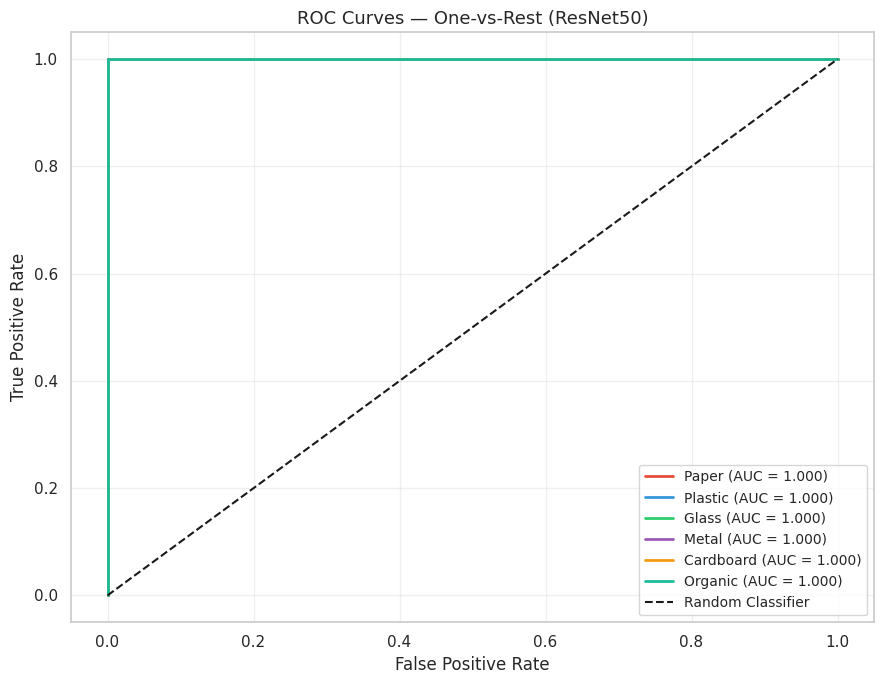


=== Phase Comparison ===
Phase 1 (Feature Extraction) Accuracy : 100.00%
Phase 2 (Fine-Tuning) Accuracy         : 100.00%

✅ Lab 5 Complete!


In [8]:
y_test_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E74C3C','#3498DB','#2ECC71','#9B59B6','#F39C12','#1ABC9C']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
ax.set_title('ROC Curves — One-vs-Rest (ResNet50)', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Phase comparison
print('\n=== Phase Comparison ===')
print(f'Phase 1 (Feature Extraction) Accuracy : {acc_p1*100:.2f}%')
print(f'Phase 2 (Fine-Tuning) Accuracy         : {acc_p2*100:.2f}%')
print(f'\n✅ Lab 5 Complete!')